(100.0, 105.0)

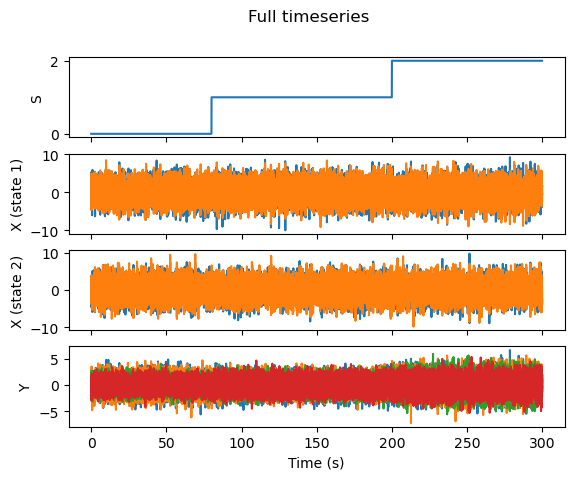

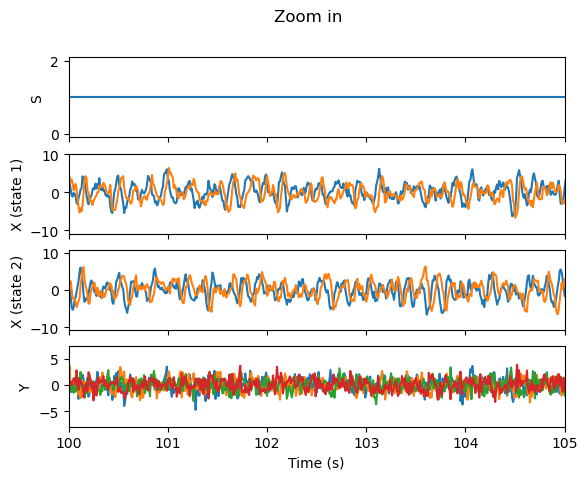

In [1]:
import matplotlib.pyplot as plt
from state_space_practice.simulate.simulate_switching_kalman import simulate_model
import jax.numpy as jnp

from jax import config

config.update("jax_enable_x64", True)

(
    fs,
    k,
    n,
    M,
    osc_freqs,
    rhos,
    var_state_nois,
    var_obs_noi,
    A,
    Q,
    R,
    B,
    Z,
    X0,
    S0,
    x_dim,
    s,
    y,
    x,
    ta,
) = simulate_model()


fig, axs = plt.subplots(2 + k, 1, sharex=True)
axs[0].plot(ta, s)
axs[0].set_ylabel("S")
for i in range(k):
    axs[1 + i].plot(ta, x[:, 2 * i : 2 * i + 2])
    axs[1 + i].set_ylabel(f"X (state {i+1})")
axs[k + 1].plot(ta, y)
axs[k + 1].set_ylabel("Y")
axs[k + 1].set_xlabel("Time (s)")
fig.suptitle("Full timeseries")

fig, axs = plt.subplots(2 + k, 1, sharex=True)
axs[0].plot(ta, s)
axs[0].set_ylabel("S")
for i in range(k):
    axs[1 + i].plot(ta, x[:, 2 * i : 2 * i + 2])
    axs[1 + i].set_ylabel(f"X (state {i+1})")
axs[k + 1].plot(ta, y)
axs[k + 1].set_ylabel("Y")
axs[k + 1].set_xlabel("Time (s)")
fig.suptitle("Zoom in")
axs[0].set_xlim([100, 105])

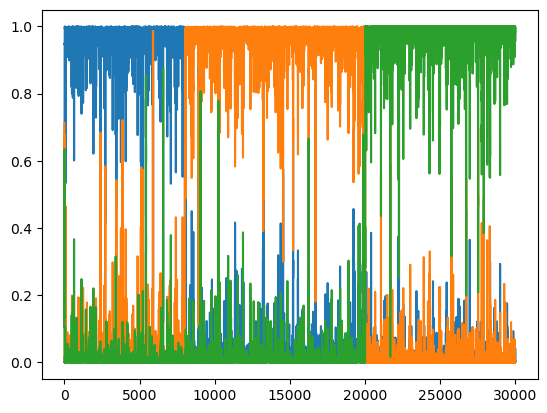

In [2]:
from state_space_practice.switching_kalman import (
    switching_kalman_filter,
)


(
    filter_mean,
    filter_cov,
    filter_discrete_state_prob,
    last_cond_cont_mean,
    marginal_log_likelihood,
) = switching_kalman_filter(
    init_state_cond_mean=jnp.tile(X0[:, None], (1, M)),
    init_state_cond_cov=jnp.tile(jnp.eye(x_dim)[:, :, None], (1, 1, M)),
    init_discrete_state_prob=jnp.ones(M) / M,
    obs=y,
    discrete_transition_matrix=Z,
    continuous_transition_matrix=A,
    process_cov=Q,
    measurement_matrix=B,
    measurement_cov=R,
)

plt.plot(filter_discrete_state_prob)

In [3]:
import numpy as np


def skf(
    y: np.ndarray,
    A: np.ndarray,
    B: np.ndarray,
    Q: np.ndarray,
    R: np.ndarray,
    X0: np.ndarray,
    Z: np.ndarray,
    pi0: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Switching Kalman Filter

    Model:
    S_t: Markov chain, P(St=j|St-1) = Zij, transition matrix
    X_t = A * X_t-1 + u_t  , u_t ~ N(0, Q)  -- oscillatory latent state
    y_t = B * X_t + v_t    , v_t ~ N(0, R)  -- observation

    Parameters
    ----------
    y : np.ndarray, shape (n_time, n_obs_dims)
        Observations
    A : np.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
       Continuous oscillatory latent states transition matrix
    B : np.ndarray, shape (n_obs_dims, n_cont_states, n_discrete_states)
        Measurement matrix (map oscillatory latent state to observations)
    Q : np.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states)
        Oscillatory state variance (process noise)
    R : np.ndarray, shape (n_obs_dims, n_obs_dims, n_discrete_states)
        Measurement variance
    X0 : np.ndarray, shape (n_cont_states,)
        Initial value of the latent state
    Z : np.ndarray, shape (n_discrete_states, n_discrete_states)
        Discrete state transition matrix
    pi0 : np.ndarray, shape (n_discrete_states,)
        Initial prob of the switching state

    Returns
    -------
    W_j : np.ndarray, shape (n_time, n_discrete_states)
        State prob. given y, P(St=j|y_1:t)
    X_j : np.ndarray, shape (n_cont_states, n_discrete_states, n_time)
        E(Xt|y_1:t, St=j)
    V_j : np.ndarray, shape (n_cont_states, n_cont_states, n_discrete_states, n_time)
        Cov(Xt|y_1:t, St=j)
    KT : np.ndarray, shape (n_cont_states, n_obs_dims, n_discrete_states, n_discrete_states)
        The Kalman gain at time T

    """

    T, n_obs_dims = y.shape
    n_cont_states = A.shape[0]  # dimension of the state
    n_discrete_states = Z.shape[0]  # number of switching states

    x_ij = np.zeros(
        (n_cont_states, n_discrete_states, n_discrete_states)
    )  # posterior state est obtained by filtering
    V_ij = np.zeros(
        (n_cont_states, n_cont_states, n_discrete_states, n_discrete_states, T + 1)
    )  # posterior error covariance matrix est
    V_cov_fil = np.zeros(
        (n_cont_states, n_cont_states, n_discrete_states, n_discrete_states, T + 1)
    )

    X = np.zeros(
        (n_cont_states, n_discrete_states, T + 1)
    )  # new state X_j obatained by collapsing x_ij
    V = np.zeros(
        (n_cont_states, n_cont_states, n_discrete_states, T + 1)
    )  # new cov V_j obatained by collapsing V_ij

    # set up initial values
    X[:, :, 0] = X0[:, None]

    V_0 = np.eye(n_cont_states)
    V[:, :, :, 0] = V_0[..., np.newaxis]

    I = np.eye(n_cont_states)

    W_j = np.zeros((T + 1, n_discrete_states))  # P(S_t=j|y_1:t)
    W_j[0, :] = pi0

    # set up variables
    y = np.vstack((np.zeros((1, n_obs_dims)), y))
    X_hat = np.zeros((n_cont_states, T + 1))
    K = np.zeros(
        (n_cont_states, n_obs_dims, n_discrete_states, n_discrete_states, T + 1)
    )
    W_ij = np.zeros((n_discrete_states, n_discrete_states, T + 1))
    L = np.zeros((n_discrete_states, n_discrete_states))
    numr = np.zeros((n_discrete_states, n_discrete_states, T + 1))
    W_norm = np.zeros((T + 1, 1))

    for t in range(1, T + 1):
        for j in range(n_discrete_states):
            A_j = A[:, :, j]
            B_j = B[:, :, j]
            Q_j = Q[:, :, j]
            R_j = R[:, :, j]

            # kalman filter
            for i in range(n_discrete_states):
                # time update for each state
                x_minus = A_j @ X[:, i, t - 1]  # prior state est
                V_minus = A_j @ V[:, :, i, t - 1] @ A_j.T + Q_j  # prior cov. est

                # measurement update
                K[:, :, i, j, t] = (V_minus @ B_j.T) @ np.linalg.inv(
                    B_j @ V_minus @ B_j.T + R_j
                )
                x_ij[:, i, j] = x_minus + K[:, :, i, j, t] @ (y[t, :].T - B_j @ x_minus)
                V_ij[:, :, i, j, t] = (I - K[:, :, i, j, t] @ B_j) @ V_minus

                # one-step covariance
                V_cov_fil[:, :, i, j, t] = (
                    (I - K[:, :, i, j, t] @ B_j) @ A_j @ V_ij[:, :, i, j, t - 1]
                )

                # likelihood of observing y_t given y_1:t-1, S_t=j, S_t-1=i
                msr_res = y[t, :] - (B_j @ x_minus).T
                covar = B_j @ V_minus @ B_j.T + R_j
                L[i, j] = (np.linalg.det(covar)) ** (-0.5) * np.exp(
                    (-0.5) * (msr_res @ np.linalg.inv(covar)) @ msr_res.T
                )

                # numerator of W_ij
                numr[i, j, t] = L[i, j] * Z[i, j] * W_j[t - 1, i]

        # denominator of W_ij
        W_norm[t] = np.sum(numr[:, :, t])

        # compute W_ij
        W_ij[:, :, t] = numr[:, :, t] / W_norm[t]

        # W_j = P(St=j|y_1:t)
        for j in range(n_discrete_states):
            W_j[t, j] = np.sum(W_ij[:, j, t])

        # g_ij = P(St-1=i|St=j,y_1:t) = weights of state components
        g = np.zeros((n_discrete_states, n_discrete_states))
        for j in range(n_discrete_states):
            for i in range(n_discrete_states):
                g[i, j] = W_ij[i, j, t] / W_j[t, j]

        # approximate (using COLLAPSE - moment matching) new state
        for j in range(n_discrete_states):
            X[:, j, t] = x_ij[:, :, j] @ g[:, j]
            V[:, :, j, t] = np.zeros((n_cont_states, n_cont_states))
            for i in range(n_discrete_states):
                m = x_ij[:, i, [j]] - X[:, [j], t]
                V[:, :, j, t] = V[:, :, j, t] + g[i, j] * (
                    V_ij[:, :, i, j, t] + m @ m.T
                )

        # [optional] collape again to get single est of X
        X_hat[:, t] = np.zeros((n_cont_states,))
        for j in range(n_discrete_states):
            X_hat[:, t] = X_hat[:, t] + W_j[t, j] * X[:, j, t]

    # Output
    W_j = W_j[1:, :]
    X_j = X[:, :, 1:]
    V_j = V[:, :, :, 1:]
    KT = K[:, :, :, :, T]

    return W_j, X_j, V_j, KT


W_j, X_j, V_j, KT = skf(y, A, B, Q, R, X0, Z, np.ones(M) / M)

In [4]:
np.allclose(filter_mean, X_j.transpose(2, 0, 1))

True

In [5]:
np.allclose(filter_cov, V_j.transpose(3, 0, 1, 2))

True

In [6]:
np.allclose(W_j, filter_discrete_state_prob)

True

In [7]:
from state_space_practice.switching_kalman import (
    switching_kalman_smoother,
)

(
    overall_smoother_mean,
    overall_smoother_covs,
    smoother_discrete_state_prob,
    smoother_joint_discrete_state_prob,
    overall_smoother_cross_cov,
    state_cond_smoother_means,
    state_cond_smoother_covs,
    pair_cond_smoother_cross_covs,
) = switching_kalman_smoother(
    filter_mean,
    filter_cov,
    filter_discrete_state_prob,
    last_cond_cont_mean,
    process_cov=Q,
    continuous_transition_matrix=A,
    discrete_state_transition_matrix=Z,
)

In [8]:
def smoother(y, A, B, Q, R, Z, X_j, V_j, W_j, KT):
    """Switching Kalman Smoother

    Model:
    S_t: Markov chain, P(St=j|St-1) = Zij, transition matrix
    X_t = A * X_t-1 + u_t  , u_t ~ N(0, Q)  -- oscillatory latent state
    y_t = B * X_t + v_t    , v_t ~ N(0, R)  -- observation

    Args:
        y (ndarray): Observations
        A (ndarray): State transition matrices
        B (ndarray): Observation matrices
        Q (ndarray): Process noise covariance matrices
        R (ndarray): Measurement noise covariance matrices
        Z (ndarray): Transition matrix associated with the switching state
        X_j (ndarray): Filtered state estimates
        V_j (ndarray): Filtered state covariances
        W_j (ndarray): State probabilities given the observations
        KT (ndarray): Kalman gain matrices

    Returns:
        M_j (ndarray): State probabilities given the observations, P(St=j|y_1:T)
        X_RTS (ndarray): Smoothed estimates of the latent state variables, E(Xt|y_1:T)
        V_RTS (ndarray): Covariances of the smoothed estimates, Cov(Xt|y_1:T)
        V_cov (ndarray): One-step covariances, Cov(Xt,Xt-1|y_1:T)

    """

    T = y.shape[0]
    dim_state = A.shape[0]  # Dimension of the state
    M = Z.shape[0]  # Number of switching states

    x_jk = np.zeros((dim_state, M, M, T))
    V_jk = np.zeros((dim_state, dim_state, M, M, T))
    V_jk_cov = np.zeros((dim_state, dim_state, M, M, T))

    X = np.zeros((dim_state, M, T))
    V = np.zeros((dim_state, dim_state, M, T))
    S = np.zeros((dim_state, dim_state, M, M, T))

    M_jk = np.zeros((T, M, M))
    M_j = np.zeros((T, M))
    I = np.eye(dim_state)

    # Set initial backward values
    for i in range(M):
        X[:, i, T - 1] = X_j[:, i, T - 1]
        V[:, :, i, T - 1] = V_j[:, :, i, T - 1]
        M_j[T - 1, i] = W_j[T - 1, i]

        for j in range(M):
            B_j = B[:, :, j]
            A_j = A[:, :, j]
            V_jk_cov[:, :, i, j, T - 1] = (
                (I - KT[:, :, i, j] @ B_j) @ A_j @ V_j[:, :, j, T - 1]
            )

    # Set up variables
    X_RTS = np.zeros((dim_state, T))
    V_RTS = np.zeros((dim_state, dim_state, T))
    U_jk = np.zeros((M, M, T))

    # print(f"t: {T - 1}")
    # print(f"next_smoother_mean: {X[:, :, T - 1]}")
    # print(f"next_smoother_cov: {V[:, :, :, T - 1]}")
    # print(f"next_disc_state_prob: {M_j[T - 1, :]}")
    # print(f"filter_mean: {X_j[:, :, T - 1]}")
    # print(f"filtered_cov: {V_j[:, :, :, T - 1]}")  # Filtered state covariances
    # # print(f"V: {V[:, :, :, T - 1]}") # New cov V_j obatained by collapsing V_ij
    # print(f"filter_discrete_state_prob: {W_j[T - 1]}")

    for t in range(T - 2, -1, -1):
        U_norm = np.zeros(M)

        # print(f"t: {t}")
        # print(f"next_smoother_mean: {X[:, :, t + 1]}")
        # print(f"next_smoother_cov: {V[:, :, :, t + 1]}")
        # print(f"next_disc_state_prob: {M_j[t + 1, :]}")
        # print(f"filter_mean: {X_j[:, :, t]}")
        # print(f"filter_cov: {V_j[:, :, :, t]}")  # Filtered state covariances
        # # print(f"V: {V[:, :, :, t + 1]}") # New cov V_j obatained by collapsing V_ij
        # print(f"filter_discrete_state_prob: {W_j[t]}")

        for j in range(M):
            A_j = A[:, :, j]
            Q_j = Q[:, :, j]

            # RTS smoother
            for k in range(M):
                # Time update for each state
                x_minus = A_j @ X_j[:, j, t]  # Prior state estimate
                V_minus = (
                    A_j @ V_j[:, :, j, t] @ A_j.T + Q_j
                )  # Prior covariance estimate

                # Smoother gain
                S[:, :, j, k, t] = V_j[:, :, j, t] @ A_j.T @ np.linalg.inv(V_minus)

                # Update
                x_jk[:, j, k, t] = X_j[:, j, t] + S[:, :, j, k, t] @ (
                    X[:, k, t + 1] - x_minus
                )
                V_jk[:, :, j, k, t] = (
                    V_j[:, :, j, t]
                    + S[:, :, j, k, t]
                    @ (V[:, :, k, t + 1] - V_minus)
                    @ S[:, :, j, k, t].T
                )
                U_jk[j, k, t] = W_j[t, j] * Z[j, k]  # Numerator of U_jk

        # print(f"cond_smoother_mean: {x_jk[:, :, :, t]}")
        # print(f"cond_smoother_cov: {V_jk[:, :, :, :, t]}")
        # print("\n")

        for k in range(M):
            U_norm[k] = np.sum(U_jk[:, k, t])

        for j in range(M):
            for k in range(M):
                U_jk[j, k, t] = U_jk[j, k, t] / U_norm[k]
                M_jk[t, j, k] = U_jk[j, k, t] * M_j[t + 1, k]  # M_jk

        # M_j = P(St=j|y_1:T)
        for j in range(M):
            M_j[t, j] = np.sum(M_jk[t, j, :])  # M_j = P(S_t|y=1:T)

        # Weights of state components
        g = np.zeros((M, M))
        for k in range(M):
            for j in range(M):
                g[j, k] = M_jk[t, j, k] / M_j[t, j]

        # Approximate (using COLLAPSE) new state
        for j in range(M):
            X[:, j, t] = x_jk[:, j, :, t] @ g[j, :]  # X_t^j
            V[:, :, j, t] = np.zeros(
                (dim_state, dim_state)
            )  # V_t^j: (dim(X) * dim(X) * M * t)
            for k in range(M):
                d = x_jk[:, j, k, [t]] - X[:, j, [t]]
                V[:, :, j, t] += g[j, k] * (V_jk[:, :, j, k, t] + d @ d.T)

        # Collapse again to get a single estimate
        for j in range(M):
            X_RTS[:, t] += M_j[t, j] * X[:, j, t]  # X_t hat
        for j in range(M):
            diff = X[:, j, [t]] - X_RTS[:, [t]]
            V_RTS[:, :, t] += M_j[t, j] * (V[:, :, j, t] + diff @ diff.T)  # V_t hat

    # One-step covariance
    V_k_cov = np.zeros((dim_state, dim_state, M, T))
    B1 = np.zeros((dim_state, M, T))
    B2 = np.zeros((dim_state, M, T))

    V_cov = np.zeros((dim_state, dim_state, T))
    B3 = np.zeros((dim_state, T))
    B4 = np.zeros((dim_state, T))

    # V_jk_cov = P(Xt,Xt+1|y_1:T,St=j,St+1=k)
    for t in range(T - 2, 0, -1):
        for j in range(M):
            A_j = A[:, :, j]
            for k in range(M):
                V_jk_cov[:, :, j, k, t] = (
                    V_j[:, :, j, t] @ S[:, :, j, k, t - 1].T
                    + S[:, :, j, k, t]
                    @ (V_jk_cov[:, :, j, k, t + 1] - A_j @ V_j[:, :, j, t])
                    @ S[:, :, j, k, t - 1].T
                )

        # Collapsing for V_k_cov
        for k in range(M):
            B1[:, k, t] = x_jk[:, :, k, t + 1] @ U_jk[:, k, t]
            B2[:, k, t] = x_jk[:, :, k, t] @ U_jk[:, k, t]
            for j in range(M):
                d1 = x_jk[:, j, k, [t + 1]] - B1[:, k, [t]]
                d2 = x_jk[:, j, k, [t]] - B2[:, k, [t]]
                V_k_cov[:, :, k, t] += U_jk[j, k, t] * (
                    V_jk_cov[:, :, j, k, t] + d1 @ d2.T
                )

        # Collapsing again for V_cov = P(Xt,Xt+1|y_1:T)
        for k in range(M):
            B3[:, t] += M_j[t, k] * X[:, k, t + 1]
            B4[:, t] += M_j[t, k] * X[:, k, t]

        for k in range(M):
            diff1 = X[:, k, [t + 1]] - B3[:, [t]]
            diff2 = X[:, k, [t]] - B4[:, [t]]
            V_cov[:, :, t] += M_j[t + 1, k] * (V_k_cov[:, :, k, t] + diff1 @ diff2.T)

    return M_j, X_RTS, V_RTS, V_cov


M_j, X_RTS, V_RTS, V_cov = smoother(y, A, B, Q, R, Z, X_j, V_j, W_j, KT)

In [9]:
np.allclose(M_j, smoother_discrete_state_prob)

True

In [10]:
X_RTS[-1].T

array([ 2.18246631,  1.69689185,  1.18095359, ..., -1.37792169,
       -1.82729975,  0.        ])

In [11]:
overall_smoother_mean[-1]

Array([ 1.67390158, -0.09360363, -0.32358193, -1.92230788], dtype=float64)

In [12]:
np.allclose(X_RTS.T, overall_smoother_mean)

False

In [13]:
X_RTS

array([[ 2.167293  ,  1.62344408,  0.45770568, ...,  0.89653396,
         1.24624151,  0.        ],
       [ 1.08311351,  1.90344647,  2.35196401, ..., -1.09904357,
        -0.70129483,  0.        ],
       [-0.26854076, -0.94433451, -1.13270046, ..., -1.94126029,
        -1.1337491 ,  0.        ],
       [ 2.18246631,  1.69689185,  1.18095359, ..., -1.37792169,
        -1.82729975,  0.        ]])

In [14]:
np.allclose(X_RTS[:, :-1].T, overall_smoother_mean[:-1])

True

(-10.0, 10.0)

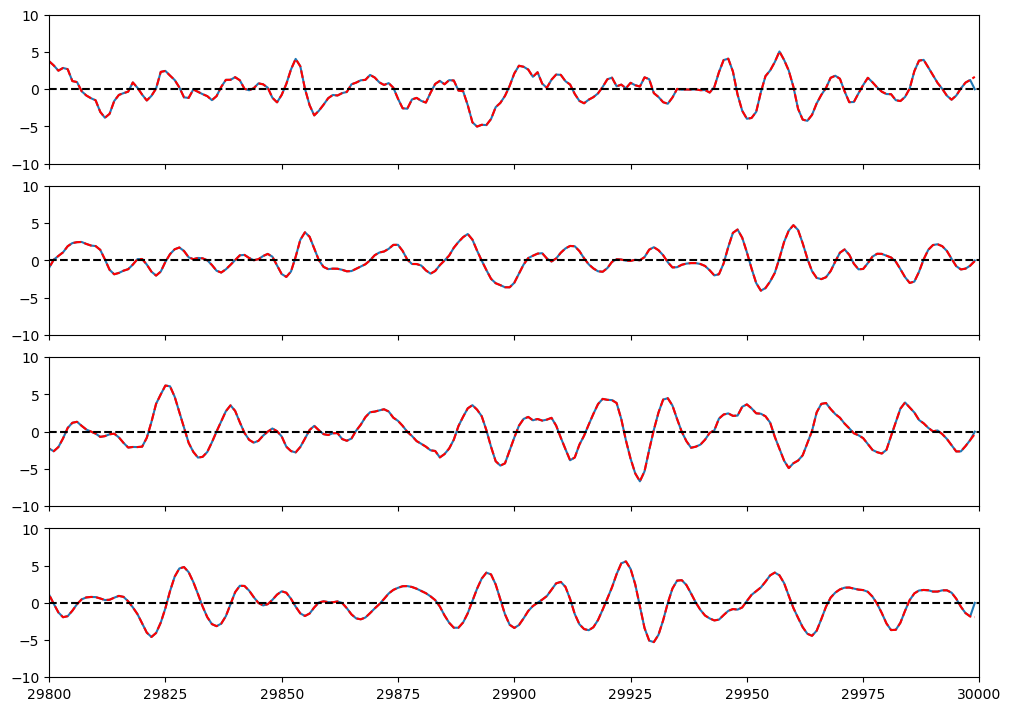

In [15]:
fig, axes = plt.subplots(
    X_RTS.shape[0],
    1,
    constrained_layout=True,
    sharex=True,
    sharey=True,
    figsize=(10, 7),
)
for i in range(X_RTS.shape[0]):
    axes[i].plot(X_RTS[i])
    axes[i].plot(overall_smoother_mean[:, i], color="red", linestyle="--")
    axes[i].axhline(0, color="black", linestyle="--")

plt.xlim([29_800, 30_000])
plt.ylim([-10, 10])

Iteration 1, log likelihood: -185121.3184782299
Iteration 2, log likelihood: -185047.17021972616
Change in log likelihood: 74.14825850373018
Iteration 3, log likelihood: -185040.33313817056
Change in log likelihood: 6.837081555597251
Iteration 4, log likelihood: -185038.14403780008
Change in log likelihood: 2.189100370480446
Iteration 5, log likelihood: -185037.08677744414
Change in log likelihood: 1.0572603559412528
Iteration 6, log likelihood: -185036.4886334628
Change in log likelihood: 0.5981439813331235
Iteration 7, log likelihood: -185036.12035499138
Change in log likelihood: 0.3682784714328591
Iteration 8, log likelihood: -185035.88157397037
Change in log likelihood: 0.23878102100570686
Iteration 9, log likelihood: -185035.72116397813
Change in log likelihood: 0.16040999224060215
Convergence reached.


Text(0, 0.5, 'Marginal log likelihood')

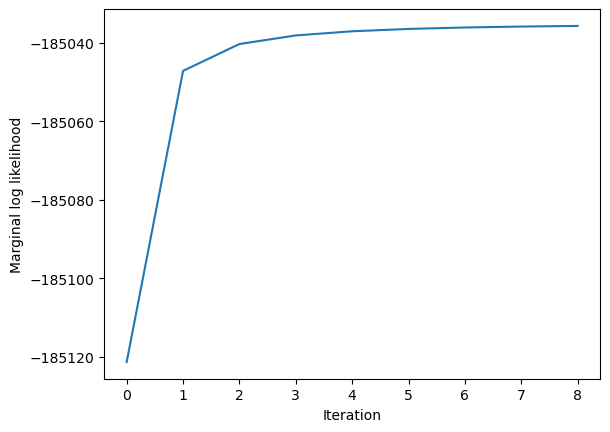

In [16]:
from state_space_practice.switching_kalman import switching_kalman_maximization_step
from state_space_practice.utils import check_converged

max_iter = 30

init_state_cond_mean = jnp.tile(X0[:, None], (1, M))
init_state_cond_cov = jnp.tile(jnp.eye(x_dim)[:, :, None], (1, 1, M))
init_discrete_state_prob = jnp.ones(M) / M
discrete_transition_matrix = Z.copy()
continuous_transition_matrix = A.copy()
process_cov = Q.copy()
measurement_matrix = B.copy()
measurement_cov = R.copy()


mll = []
for i in range(max_iter):
    (
        filter_mean,
        filter_cov,
        filter_discrete_state_prob,
        last_cond_cont_mean,
        marginal_log_likelihood,
    ) = switching_kalman_filter(
        init_state_cond_mean=init_state_cond_mean,
        init_state_cond_cov=init_state_cond_cov,
        init_discrete_state_prob=init_discrete_state_prob,
        obs=y,
        discrete_transition_matrix=discrete_transition_matrix,
        continuous_transition_matrix=continuous_transition_matrix,
        process_cov=process_cov,
        measurement_matrix=measurement_matrix,
        measurement_cov=measurement_cov,
    )
    (
        overall_smoother_mean,
        overall_smoother_covs,
        smoother_discrete_state_prob,
        smoother_joint_discrete_state_prob,
        overall_smoother_cross_cov,
        state_cond_smoother_means,
        state_cond_smoother_covs,
        pair_cond_smoother_cross_covs,
    ) = switching_kalman_smoother(
        filter_mean,
        filter_cov,
        filter_discrete_state_prob,
        last_cond_cont_mean,
        process_cov=Q,
        continuous_transition_matrix=A,
        discrete_state_transition_matrix=Z,
    )

    # (
    #     continuous_transition_matrix,
    #     measurement_matrix,
    #     process_cov,
    #     measurement_cov,
    #     initial_state_mean,
    #     initial_state_cov,
    #     discrete_transition_matrix,
    #     init_discrete_state_prob,
    # ) = switching_kalman_maximization_step(
    #     y,
    #     state_cond_smoother_means,
    #     state_cond_smoother_covs,
    #     smoother_discrete_state_prob,
    #     smoother_joint_discrete_state_prob,
    #     pair_cond_smoother_cross_covs,
    # )
    (
        _,
        measurement_matrix,
        _,
        measurement_cov,
        initial_state_mean,
        initial_state_cov,
        discrete_transition_matrix,
        init_discrete_state_prob,
    ) = switching_kalman_maximization_step(
        y,
        state_cond_smoother_means,
        state_cond_smoother_covs,
        smoother_discrete_state_prob,
        smoother_joint_discrete_state_prob,
        pair_cond_smoother_cross_covs,
    )

    print(f"Iteration {i + 1}, log likelihood: {marginal_log_likelihood}")
    mll.append(marginal_log_likelihood)
    if i > 0:
        print(f"Change in log likelihood: {mll[-1] - mll[-2]}")
        if check_converged(mll[-1], mll[-2], tolerance=1e-6)[0]:
            print("Convergence reached.")
            break


plt.plot(mll)
plt.xlabel("Iteration")
plt.ylabel("Marginal log likelihood")

INFO:state_space_practice.oscillator_models:Iteration 1/100	Log-Likelihood: -204397.7200	Change: inf
INFO:state_space_practice.oscillator_models:Iteration 2/100	Log-Likelihood: -190862.5928	Change: 13535.1272
INFO:state_space_practice.oscillator_models:Iteration 3/100	Log-Likelihood: -187965.8580	Change: 2896.7348
INFO:state_space_practice.oscillator_models:Iteration 4/100	Log-Likelihood: -186860.9505	Change: 1104.9074
INFO:state_space_practice.oscillator_models:Iteration 5/100	Log-Likelihood: -186314.2043	Change: 546.7462
INFO:state_space_practice.oscillator_models:Iteration 6/100	Log-Likelihood: -186073.4433	Change: 240.7611
INFO:state_space_practice.oscillator_models:Iteration 7/100	Log-Likelihood: -185955.4181	Change: 118.0252
INFO:state_space_practice.oscillator_models:Iteration 8/100	Log-Likelihood: -185887.4895	Change: 67.9286
INFO:state_space_practice.oscillator_models:Iteration 9/100	Log-Likelihood: -185843.5159	Change: 43.9735
INFO:state_space_practice.oscillator_models:Itera

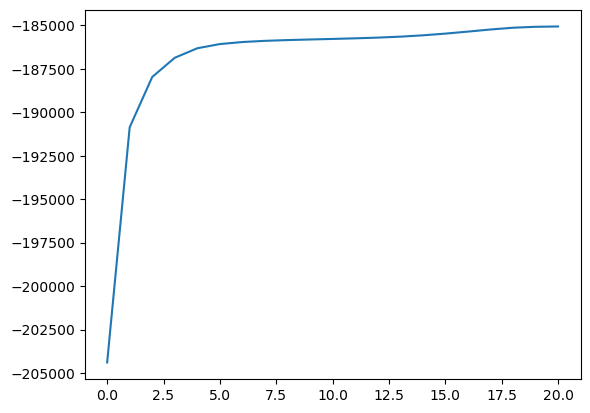

In [17]:
from state_space_practice.oscillator_models import CommonOscillatorModel
import jax.random

# Ensure freqs has the same length as n_oscillators
freqs = jnp.array(np.tile(osc_freqs, int(np.ceil(y.shape[1] / len(osc_freqs))))[:y.shape[1]])

co_model = CommonOscillatorModel(
    n_oscillators=y.shape[1],
    n_discrete_states=M,
    n_sources=y.shape[1],
    sampling_freq=fs,
    freqs=freqs,
    auto_regressive_coef=jnp.array(np.tile(rhos, int(np.ceil(y.shape[1] / len(rhos))))[:y.shape[1]]),
    process_variance=jnp.array(np.tile(var_state_nois, int(np.ceil(y.shape[1] / len(var_state_nois))))[:y.shape[1]]),
    measurement_variance=var_obs_noi,
)

key_main = jax.random.PRNGKey(42)
marginal_log_likelihoods = co_model.fit(observations=y, key=key_main)

plt.plot(marginal_log_likelihoods)

In [18]:
co_model.get_oscillator_influence_on_node()

Array([[[0.22055066, 0.17384924, 0.17690203],
        [0.27370067, 0.37789145, 0.10330855],
        [0.04145049, 0.16461983, 0.11501303],
        [0.11540238, 0.20415188, 0.18445284]],

       [[0.08899245, 0.14498704, 0.15387602],
        [0.14310733, 0.37543847, 0.04252608],
        [0.22636817, 0.16207539, 0.14988857],
        [0.27386301, 0.23735384, 0.20166975]],

       [[0.04883119, 0.15457101, 0.1575919 ],
        [0.02328348, 0.36683212, 0.10286433],
        [0.0143912 , 0.16399141, 0.08187362],
        [0.04386666, 0.22758871, 0.12751612]],

       [[0.03483421, 0.14101985, 0.1518265 ],
        [0.03104477, 0.23236973, 0.0976199 ],
        [0.03967758, 0.22520004, 0.09955035],
        [0.05161403, 0.19209343, 0.12548339]]], dtype=float64)

In [19]:
co_model.get_phase_difference(node1_ind=0, node2_ind=1, oscillator_ind=0)

Array([-1.27821924,  3.19563867, -1.48806746], dtype=float64)

In [20]:
from state_space_practice.oscillator_models import CorrelatedNoiseModel

# Ensure all parameters have correct shapes
n_oscillators = y.shape[1]
freqs = jnp.array(np.tile(osc_freqs, int(np.ceil(n_oscillators / len(osc_freqs))))[:n_oscillators])
auto_regressive_coef = jnp.array(np.tile(rhos, int(np.ceil(n_oscillators / len(rhos))))[:n_oscillators])
process_variance = jnp.tile(
    jnp.array(np.tile(var_state_nois, int(np.ceil(n_oscillators / len(var_state_nois))))[:n_oscillators])[:, None],
    (1, M)
)

cn_model = CorrelatedNoiseModel(
    n_oscillators=n_oscillators,
    n_discrete_states=M,
    sampling_freq=fs,
    freqs=freqs,
    auto_regressive_coef=auto_regressive_coef,
    process_variance=process_variance,
    measurement_variance=var_obs_noi,
    phase_difference=jnp.zeros((n_oscillators, n_oscillators, M)),
    coupling_strength=jnp.zeros((n_oscillators, n_oscillators, M)),
)
key_main = jax.random.PRNGKey(42)
cn_model.fit(observations=y, key=key_main)

# marginal_log_likelihoods = cn_model.fit(observations=y, key=key_main)
# plt.plot(marginal_log_likelihoods)

INFO:state_space_practice.oscillator_models:Iteration 1/100	Log-Likelihood: -207968.5025	Change: inf
INFO:state_space_practice.oscillator_models:Iteration 2/100	Log-Likelihood: -204601.7778	Change: 3366.7247
INFO:state_space_practice.oscillator_models:Iteration 3/100	Log-Likelihood: -203085.1139	Change: 1516.6639
INFO:state_space_practice.oscillator_models:Iteration 4/100	Log-Likelihood: -202248.9132	Change: 836.2007
INFO:state_space_practice.oscillator_models:Iteration 5/100	Log-Likelihood: -201708.0211	Change: 540.8921
INFO:state_space_practice.oscillator_models:Iteration 6/100	Log-Likelihood: -201322.2219	Change: 385.7992
INFO:state_space_practice.oscillator_models:Iteration 7/100	Log-Likelihood: -201036.0391	Change: 286.1828
INFO:state_space_practice.oscillator_models:Iteration 8/100	Log-Likelihood: -200822.1130	Change: 213.9262
INFO:state_space_practice.oscillator_models:Iteration 9/100	Log-Likelihood: -200662.7605	Change: 159.3525
INFO:state_space_practice.oscillator_models:Itera

[Array(-207968.50251024, dtype=float64),
 Array(-204601.77782547, dtype=float64),
 Array(-203085.11391726, dtype=float64),
 Array(-202248.91324431, dtype=float64),
 Array(-201708.02110015, dtype=float64),
 Array(-201322.22189964, dtype=float64),
 Array(-201036.03910977, dtype=float64),
 Array(-200822.11295723, dtype=float64),
 Array(-200662.76048083, dtype=float64),
 Array(-200544.70514125, dtype=float64),
 Array(-200457.6276297, dtype=float64),
 Array(-200393.58158633, dtype=float64),
 Array(-200346.5494737, dtype=float64),
 Array(-200312.03586361, dtype=float64),
 Array(-200286.7126894, dtype=float64),
 Array(-200268.12952591, dtype=float64)]

In [21]:
from state_space_practice.oscillator_models import DirectedInfluenceModel

di_model = DirectedInfluenceModel(
    n_oscillators=n_oscillators,
    n_discrete_states=M,
    sampling_freq=fs,
    freqs=freqs,
    auto_regressive_coef=auto_regressive_coef,
    process_variance=jnp.array(np.tile(var_state_nois, int(np.ceil(y.shape[1] / len(var_state_nois))))[:y.shape[1]]),
    measurement_variance=var_obs_noi,
    phase_difference=jnp.zeros((n_oscillators, n_oscillators, M)),
    coupling_strength=jnp.zeros((n_oscillators, n_oscillators, M)),
)
key_main = jax.random.PRNGKey(42)
di_model.fit(observations=y, key=key_main)

INFO:state_space_practice.oscillator_models:Iteration 1/100	Log-Likelihood: -207967.8522	Change: inf
INFO:state_space_practice.oscillator_models:Iteration 2/100	Log-Likelihood: -196014.3270	Change: 11953.5252
INFO:state_space_practice.oscillator_models:Iteration 3/100	Log-Likelihood: -194405.4180	Change: 1608.9090
INFO:state_space_practice.oscillator_models:Iteration 4/100	Log-Likelihood: -193551.1330	Change: 854.2850
INFO:state_space_practice.oscillator_models:Iteration 5/100	Log-Likelihood: -193018.1667	Change: 532.9664
INFO:state_space_practice.oscillator_models:Iteration 6/100	Log-Likelihood: -192688.8481	Change: 329.3185
INFO:state_space_practice.oscillator_models:Iteration 7/100	Log-Likelihood: -192467.6031	Change: 221.2450
INFO:state_space_practice.oscillator_models:Iteration 8/100	Log-Likelihood: -192323.5520	Change: 144.0511
INFO:state_space_practice.oscillator_models:Iteration 9/100	Log-Likelihood: -192221.0083	Change: 102.5437
INFO:state_space_practice.oscillator_models:Iter

[Array(-207967.85218384, dtype=float64),
 Array(-196014.32696777, dtype=float64),
 Array(-194405.41799042, dtype=float64),
 Array(-193551.13302078, dtype=float64),
 Array(-193018.16666666, dtype=float64),
 Array(-192688.84814493, dtype=float64),
 Array(-192467.60311204, dtype=float64),
 Array(-192323.55196478, dtype=float64),
 Array(-192221.00825062, dtype=float64),
 Array(-192151.0245525, dtype=float64),
 Array(-192098.0333624, dtype=float64),
 Array(-192060.04163074, dtype=float64),
 Array(-192029.54226453, dtype=float64),
 Array(-192006.69057969, dtype=float64),
 Array(-191987.49330072, dtype=float64)]